In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os 
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [4]:
dataset = Path('/kaggle/input/datasets/himanshuydv11/facial-emotion-dataset/facial_emotion_dataset/dataset')

emotion_df = dataset

In [5]:
emotion_df

PosixPath('/kaggle/input/datasets/himanshuydv11/facial-emotion-dataset/facial_emotion_dataset/dataset')

In [10]:
emotion_recognition = []

def convert_df(folder_Path):
    for folder_name in os.listdir(folder_Path):
        folder_path = os.path.join(folder_Path, folder_name)
    
        if os.path.isdir(folder_path):  # Check if it is a directory
            for image_name in os.listdir(folder_path):
                if image_name.endswith(('.png', '.jpg', '.jpeg')):  # Filter image types
                    image_path = os.path.join(folder_path, image_name)
                    if folder_Path == emotion_df:
                        emotion_recognition.append({'image_path': image_path, 'label': folder_name})


emotion_df = convert_df(emotion_df)
emotion_df = pd.DataFrame(emotion_recognition)

In [11]:
emotion_df

,image_path,label
0,/kaggle/input/datasets/himanshuydv11/facial-em...,Surprise
1,/kaggle/input/datasets/himanshuydv11/facial-em...,Surprise
2,/kaggle/input/datasets/himanshuydv11/facial-em...,Surprise
3,/kaggle/input/datasets/himanshuydv11/facial-em...,Surprise
4,/kaggle/input/datasets/himanshuydv11/facial-em...,Surprise
...,...,...
15147,/kaggle/input/datasets/himanshuydv11/facial-em...,Ahegao
15148,/kaggle/input/datasets/himanshuydv11/facial-em...,Ahegao
15149,/kaggle/input/datasets/himanshuydv11/facial-em...,Ahegao
15150,/kaggle/input/datasets/himanshuydv11/facial-em...,Ahegao


In [13]:
def load_and_preprocess_data(emotion_df, input_width, input_height):
    images = []
    labels = []
    
    for index, row in emotion_df.iterrows():
        image_path = row['image_path']
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        image = cv2.resize(image, (input_width, input_height))  # Resize
        
        images.append(image)
        labels.append(row['label'])
    
    images = np.array(images) / 255.0  # Normalize images
    images = np.expand_dims(images, axis=-1)  # Add channels dimension
    
    return images, np.array(labels)


In [14]:
def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Adjust for classification
    return model


In [15]:
# Preparing the dataset
input_width, input_height = 200, 200  # Modify as needed
images, labels = load_and_preprocess_data(emotion_df, input_width, input_height)

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(images, labels_categorical, test_size=0.2, random_state=42)

# Build the model
model = create_model((input_width, input_height, 1), len(le.classes_))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-17 12:26:54.624867: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.3350 - loss: 1.9526 - val_accuracy: 0.4731 - val_loss: 1.2848
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.6509 - loss: 0.8874 - val_accuracy: 0.5582 - val_loss: 1.1006
Epoch 4/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.7607 - loss: 0.6280 - val_accuracy: 0.5612 - val_loss: 1.1796
Epoch 5/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.8685 - loss: 0.3771 - val_accuracy: 0.5589 - val_loss: 1.3659
Epoch 6/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.9402 - loss: 0.1901 - val_accuracy: 0.5318 - val_loss: 1.8574
Epoch 7/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 0.9744 - loss: 0.0937 - val_accuracy: 0.5460 - val_loss: 2.4468
Epoch 8/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 465s 1s/step - accuracy: 0.9878 - loss: 0.0493 - val_accuracy: 0.5457 - val_loss: 2.6700
Epoch 9/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - accuracy: 0.9909 - loss: 0.0360 - val_accu

In [16]:
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy:.2f}')


95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 287ms/step - accuracy: 0.5251 - loss: 2.9275
Validation Accuracy: 0.53


In [17]:
model.save('emotion_model.h5')


In [3]:
# Load your trained model
model_path = '/kaggle/input/models/adityamodi20/emotion-model2/pytorch/default/1/emotion_model(2).h5'  # Path to your .h5 model
model = load_model(model_path)



labels = ['ahegao', 'angry', 'happy', 'neutral', 'sad', 'surprise']
le = LabelEncoder()
le.fit(labels) 


2026-02-17 16:24:22.322688: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


LabelEncoder()

In [4]:
def preprocess_image(image_path, input_width, input_height):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    image = cv2.resize(image, (input_width, input_height))  # Resize

    # Normalize the image
    image = image / 255.0  # Scale pixel values to [0, 1]
    
    # Add channel dimension and batch dimension
    image = np.expand_dims(image, axis=-1)  # Shape: (height, width, 1)
    image = np.expand_dims(image, axis=0)   # Shape: (1, height, width, 1)
    
    return image


In [ ]:
import random 

In [9]:
def predict_emotion_on_image(model, image_path, input_width, input_height):
    processed_image = preprocess_image(image_path, input_width, input_height)
    
    # Make prediction
    predictions = model.predict(processed_image)
    # Get the predicted class index
    predicted_class_index = np.argmax(predictions[0])
    
    return le.inverse_transform([predicted_class_index])[0]  # Convert back to label

# Example usage with a list of test images
test_images = ['/kaggle/input/datasets/aklimarimi/8-facial-expressions-for-yolo/9 Facial Expressions you need/train/images/0b33836b914f544c31e3a642ccccbb94114040537440b4df3b9250d025fc39a5_-_20_-_-_20210209150051-010-013_jpg.rf.5a888b8261bcf4613dfa5f2fcc9ab6d5.jpg', '/kaggle/input/models/adityamodi20/face-images/tflite/default/1/pexels-heitorverdifotos-2169434.jpg']  # Update with actual paths
input_width, input_height = 200, 200  # Ensure these match your model input dimensions

predictions = {}
for img in test_images:
    predicted_emotion = predict_emotion_on_image(model, img, input_width, input_height)
    predictions[img] = predicted_emotion

# Display results
for img_path, emotion in predictions.items():
    print(f'Image: {img_path} - Predicted Emotion: {emotion}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Image: /kaggle/input/datasets/aklimarimi/8-facial-expressions-for-yolo/9 Facial Expressions you need/train/images/0b33836b914f544c31e3a642ccccbb94114040537440b4df3b9250d025fc39a5_-_20_-_-_20210209150051-010-013_jpg.rf.5a888b8261bcf4613dfa5f2fcc9ab6d5.jpg - Predicted Emotion: neutral
Image: /kaggle/input/models/adityamodi20/face-images/tflite/default/1/pexels-heitorverdifotos-2169434.jpg - Predicted Emotion: happy


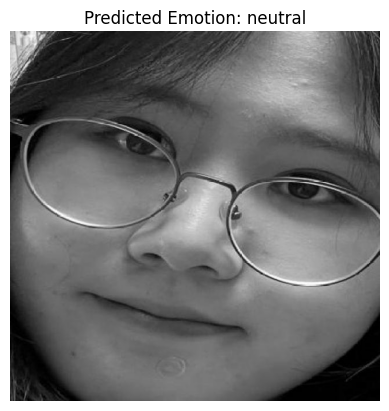

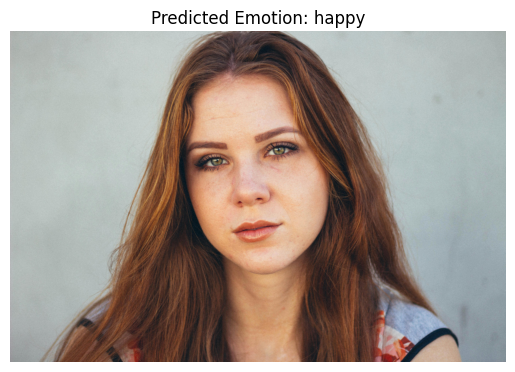

In [10]:
for img_path, emotion in predictions.items():
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
    plt.imshow(img)
    plt.title(f'Predicted Emotion: {emotion}')
    plt.axis('off')
    plt.show()


In [1]:
from sklearn.metrics import classification_report, accuracy_score

In [13]:
import os
import time
from PIL import Image
import numpy as np
from tensorflow.keras.models import load_model

EMOTION_CLASSES = {
    'Ahegao': 0,
    'Angry': 1,
    'Happy': 2,
    'Neutral': 3,
    'Sad': 4,
    'Surprise': 5
}
CLASS_TO_EMOTION = {v: k for k, v in EMOTION_CLASSES.items()}

model_path = "/kaggle/input/models/adityamodi20/emotion-model2/pytorch/default/1/emotion_model(2).h5"
base_dir = "/kaggle/input/models/adityamodi20/testing-image/tflite/default/1/hualcosa DLBAIPEAI01_edge_ai main evaluation_images"
img_size = (200, 200)

def extract_true_label_from_filename(filename):
    fname = filename.lower()
    if 'happy' in fname:
        return "Happy"
    elif 'sad' in fname:
        return "Sad"
    elif 'angry' in fname:
        return "Angry"
    elif 'neutral' in fname:
        return "Neutral"
    elif 'surprise' in fname or 'surpr' in fname:
        return "Surprise"
    elif 'ahegao' in fname:
        return "Ahegao"
    else:
        return "Unknown"

def load_and_preprocess(image_path, img_size):
    try:
        img = Image.open(image_path).convert('L')
        img = img.resize(img_size, Image.Resampling.LANCZOS)
        arr = np.array(img, dtype=np.float32)
        arr = np.expand_dims(arr, axis=-1)   # channel
        arr = np.expand_dims(arr, axis=0)    # batch
        arr /= 255.0
        return arr
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

def predict_emotions(model, img_array):
    start = time.perf_counter()
    preds = model.predict(img_array, verbose=0)
    end = time.perf_counter()
    infer_time_ms = (end - start) * 1000.0
    pred_idx = int(np.argmax(preds, axis=1)[0])
    pred_label = CLASS_TO_EMOTION.get(pred_idx, "Unknown")
    return pred_label, pred_idx, infer_time_ms

def test_model(model_path, image_folder, img_size):
    print(f"Loading model from {model_path}...")
    model = load_model(model_path)
    print("Model loaded successfully!\n")

    true_labels = []
    pred_labels = []

    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    image_files = []
    for root, _, files in os.walk(image_folder):
        for f in files:
            if os.path.splitext(f)[1].lower() in valid_extensions:
                image_files.append(os.path.join(root, f))

    if not image_files:
        print("No images found.")
        return

    for img_path in image_files:
        img_array = load_and_preprocess(img_path, img_size)
        if img_array is None:
            continue

        pred_label, pred_idx, infer_ms = predict_emotions(model, img_array)
        true_label = extract_true_label_from_filename(os.path.basename(img_path))
        true_labels.append(true_label)
        pred_labels.append(pred_label)

       
        print(f"File: {os.path.basename(img_path)} | Pred: {pred_label} ({pred_idx}) | True: {true_label} | Inference: {infer_ms:.2f} ms")



    pairs = [(t, p) for t, p in zip(true_labels, pred_labels) if t in EMOTION_CLASSES and p in EMOTION_CLASSES]
    if not pairs:
        print("No valid labeled predictions to report.")
        return
    t_filtered, p_filtered = zip(*pairs)

    target_names = [k for k, v in sorted(EMOTION_CLASSES.items(), key=lambda x: x[1])]
    print("\n" + "="*40)
    print("Classification Report")
    print("="*40)
    print(classification_report(t_filtered, p_filtered, target_names=target_names))


if __name__ == "__main__":
    test_model(model_path, base_dir, img_size)

    
   
    

Loading model from /kaggle/input/models/adityamodi20/emotion-model2/pytorch/default/1/emotion_model(2).h5...


Model loaded successfully!

File: young_woman_sad_3.jpg | Pred: Happy (2) | True: Sad | Inference: 149.02 ms
File: young_woman_happy_2.jpg | Pred: Happy (2) | True: Happy | Inference: 94.88 ms
File: elderly_woman_happy_3.jpg | Pred: Sad (4) | True: Happy | Inference: 92.57 ms
File: young_man_happy_3.jpg | Pred: Ahegao (0) | True: Happy | Inference: 93.51 ms
File: young_man_sad_1.jpg | Pred: Ahegao (0) | True: Sad | Inference: 93.21 ms
File: elderly_man_happy_1.jpg | Pred: Sad (4) | True: Happy | Inference: 92.28 ms
File: young_man_sad_2.jpg | Pred: Happy (2) | True: Sad | Inference: 93.79 ms
File: young_woman_sad_1.jpg | Pred: Happy (2) | True: Sad | Inference: 94.85 ms
File: elderly_man_sad_3.jpg | Pred: Sad (4) | True: Sad | Inference: 86.18 ms
File: elderly_man_happy_2.jpg | Pred: Happy (2) | True: Happy | Inference: 90.10 ms
File: elderly_man_happy_3.jpg | Pred: Surprise (5) | True: Happy | Inference: 89.47 ms
File: young_man_happy_1.jpg | Pred: Neutral (3) | True: Happy | Inferenc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
